TLS line parameters:
a = 0.773562, b = -0.633721, c = -3.794192
Equation: 0.773562x + -0.633721y + -3.794192 = 0


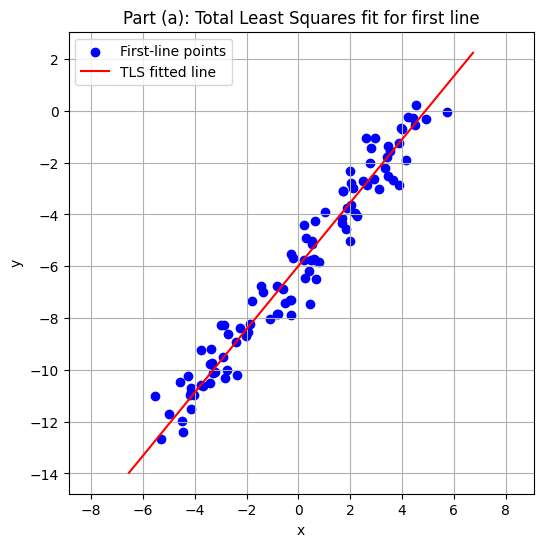

In [1]:
#part a)

import numpy as np
import matplotlib.pyplot as plt

# Load data
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

# First line points only
x1 = D[:, 0]
y1 = D[:, 3]

# Stack points
P = np.column_stack((x1, y1))
# Compute centroid
centroid = np.mean(P, axis=0)
# Center the data
P_centered = P - centroid
# SVD
U, S, Vt = np.linalg.svd(P_centered)
# Normal vector of the best-fit TLS line
normal = Vt[-1]   # smallest singular value direction
a, b = normal
# Compute c using centroid
c = -(a * centroid[0] + b * centroid[1])

print("TLS line parameters:")
print(f"a = {a:.6f}, b = {b:.6f}, c = {c:.6f}")
print(f"Equation: {a:.6f}x + {b:.6f}y + {c:.6f} = 0")

# Plot
plt.figure(figsize=(6,6))
plt.scatter(x1, y1, color='blue', label='First-line points')

# Generate line points
x_plot = np.linspace(min(x1)-1, max(x1)+1, 100)
if abs(b) > 1e-8:
    y_plot = -(a * x_plot + c) / b
    plt.plot(x_plot, y_plot, 'r-', label='TLS fitted line')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Part (a): Total Least Squares fit for first line")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

Line 1: y = -0.510480x + 1.890193
Line 2: y = 1.057480x + 0.919642
Line 3: y = -0.496067x + 2.382719


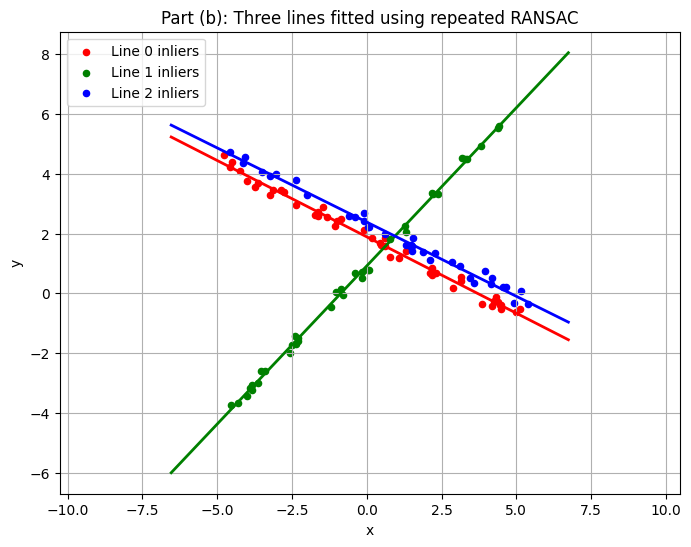

In [2]:
#part b)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, RANSACRegressor

# Load data
D = np.genfromtxt("lines.csv", delimiter=",", skip_header=1)

# Use all points
X_cols = D[:, :3]
Y_cols = D[:, 3:]

X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

# Reshape for sklearn
X_remaining = X_all.reshape(-1, 1)
Y_remaining = Y_all.copy()

models = []
inlier_masks = []
all_points_history = []

for i in range(3):
    ransac = RANSACRegressor(
        estimator=LinearRegression(),
        min_samples=2,
        residual_threshold=0.3,   # may need small tuning
        max_trials=1000,
        random_state=42
    )
    ransac.fit(X_remaining, Y_remaining)
    inlier_mask = ransac.inlier_mask_
    outlier_mask = ~inlier_mask
    models.append(ransac)
    inlier_masks.append((X_remaining.copy(), Y_remaining.copy(), inlier_mask.copy()))
    # Remove inliers and continue
    X_remaining = X_remaining[outlier_mask]
    Y_remaining = Y_remaining[outlier_mask]

# Print parameters
for i, model in enumerate(models, start=1):
    m = model.estimator_.coef_[0]
    b = model.estimator_.intercept_
    print(f"Line {i}: y = {m:.6f}x + {b:.6f}")

# Plot results
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']

for i, (model, data) in enumerate(zip(models, inlier_masks)):
    X_curr, Y_curr, mask = data
    X_in = X_curr[mask]
    Y_in = Y_curr[mask]
    
    plt.scatter(X_in, Y_in, s=20, color=colors[i], label=f'Line {i} inliers')
    
    x_plot = np.linspace(np.min(X_all)-1, np.max(X_all)+1, 100).reshape(-1, 1)
    y_plot = model.predict(x_plot)
    plt.plot(x_plot, y_plot, color=colors[i], linewidth=2)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Part (b): Three lines fitted using repeated RANSAC")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()